In [44]:
!pip install pulp -q
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import pulp
from datetime import datetime

print("Librerie caricate. Versione Python:")
import sys
print(sys.version)

Librerie caricate. Versione Python:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [45]:
!pip install pulp -q
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import pulp
from datetime import datetime

print("Librerie caricate. Versione Python:")
import sys
print(sys.version)

Librerie caricate. Versione Python:
3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]


In [65]:
# --- Coordinate: Valencia (default) — cambia se il progetto punta altrove ---
LAT = 39.47
LON = -0.38

# --- Parametri impianto FV ---
PEAK_POWER_KW = 2.2      # potenza di picco impianto, kW
SYSTEM_LOSS_PCT = 14     # perdite di sistema tipiche (inverter, cablaggi, sporco), %
TILT = 30                # inclinazione pannelli, gradi (ottimale per Valencia ~30-35°)
AZIMUTH = 0               # 0 = sud (convenzione PVGIS: 0=sud, negativo=est, positivo=ovest)

def scarica_pvgis(anno_inizio, anno_fine, lat=LAT, lon=LON):
    """
    Scarica serie oraria di produzione FV da PVGIS.
    anno_inizio/anno_fine: interi, es. 2023, 2023 (PVGIS usa anni storici
    di dati meteo reali, non l'anno corrente — non esistono dati PVGIS
    per il 2026 in corso, useremo un anno storico completo come proxy
    realistico, pratica standard nel settore).
    """
    params = {
        "lat": lat,
        "lon": lon,
        "startyear": anno_inizio,
        "endyear": anno_fine,
        "pvcalculation": 1,
        "peakpower": PEAK_POWER_KW,
        "loss": SYSTEM_LOSS_PCT,
        "angle": TILT,
        "aspect": AZIMUTH,
        "outputformat": "json",
    }
    r = requests.get(
        "https://re.jrc.ec.europa.eu/api/v5_3/seriescalc",
        params=params,
        timeout=60,
    )
    r.raise_for_status()
    dati = r.json()
    righe = dati["outputs"]["hourly"]
    df = pd.DataFrame(righe)
    # 'time' arriva come stringa tipo '20200101:0010' (UTC, minuto :10 fisso)
    df["datetime"] = pd.to_datetime(df["time"], format="%Y%m%d:%H%M")
    df = df.rename(columns={"P": "potenza_fv_w"})
    df["potenza_fv_kw"] = df["potenza_fv_w"] / 1000
    return df[["datetime", "potenza_fv_kw"]]

# Esempio: un anno intero di dati storici (2023, anno recente con dataset
# meteo PVGIS completo e stabile)
df_fv = scarica_pvgis(2023, 2023)
print(df_fv.shape)
df_fv.head()

(8760, 2)


,datetime,potenza_fv_kw
0,2023-01-01 00:10:00,0.0
1,2023-01-01 01:10:00,0.0
2,2023-01-01 02:10:00,0.0
3,2023-01-01 03:10:00,0.0
4,2023-01-01 04:10:00,0.0


In [66]:
def scarica_redata(start_date, end_date, serie_id):
    """
    serie_id: '1001' = PVPC (prezzo acquisto), '600' = spot/PBF (prezzo vendita)
    start_date, end_date: stringhe 'YYYY-MM-DDT00:00'
    """
    url = "https://apidatos.ree.es/es/datos/mercados/precios-mercados-tiempo-real"
    params = {
        "start_date": start_date,
        "end_date": end_date,
        "time_trunc": "hour",
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    dati = r.json()

    serie_disponibili = [s["id"] for s in dati.get("included", [])]
    if serie_id not in serie_disponibili:
        print(f"ATTENZIONE — blocco {start_date} → {end_date}")
        print(f"Serie richiesta: {serie_id}")
        print(f"Serie disponibili in questa risposta: {serie_disponibili}")
        raise ValueError(
            f"Serie {serie_id} non trovata per il periodo {start_date}-{end_date}"
        )

    for serie in dati["included"]:
        if serie["id"] == serie_id:
            valori = serie["attributes"]["values"]
            df = pd.DataFrame(valori)
            df["datetime"] = pd.to_datetime(df["datetime"], utc=True).dt.tz_convert("Europe/Madrid")
            df = df.rename(columns={"value": f"prezzo_{serie_id}"})
            return df[["datetime", f"prezzo_{serie_id}"]]

def scarica_redata_esteso(start_date, end_date, serie_id, giorni_per_blocco=25):
    """Scarica a blocchi e concatena, per evitare limiti di REData su
    range troppo lunghi in una sola chiamata."""
    inizio = pd.Timestamp(start_date)
    fine = pd.Timestamp(end_date)
    blocchi = []
    cursore = inizio
    while cursore < fine:
        prossimo = min(cursore + pd.Timedelta(days=giorni_per_blocco), fine)
        s = cursore.strftime("%Y-%m-%dT%H:%M")
        e = prossimo.strftime("%Y-%m-%dT%H:%M")
        blocchi.append(scarica_redata(s, e, serie_id))
        cursore = prossimo
    return pd.concat(blocchi, ignore_index=True).drop_duplicates(subset="datetime")

# Esempio: gennaio-giugno 2023, coerente con l'anno FV scelto sopra
df_pvpc = scarica_redata_esteso("2023-01-01T00:00", "2023-07-01T00:00", "1001")
df_spot = scarica_redata_esteso("2023-01-01T00:00", "2023-07-01T00:00", "600")

print(df_pvpc.shape, df_spot.shape)
df_pvpc.head()

(4344, 2) (4344, 2)


,datetime,prezzo_1001
0,2023-01-01 00:00:00+01:00,41.45
1,2023-01-01 01:00:00+01:00,43.01
2,2023-01-01 02:00:00+01:00,58.07
3,2023-01-01 03:00:00+01:00,60.69
4,2023-01-01 04:00:00+01:00,62.91


In [67]:
import numpy as np

def genera_profilo_giornaliero(consumo_medio_kwh_giorno, tipo="residenziale_standard"):
    """
    Restituisce 24 pesi (frazione del consumo giornaliero per ora),
    che sommano a 1.0. Forma-tipo bimodale: picco mattutino leggero
    (7-9h) e picco serale marcato (20-23h), consumo minimo notturno.
    """
    ore = np.arange(24)
    # Componenti gaussiane per i due picchi + base notturna
    base = 0.015  # consumo di fondo (frigorifero, stand-by) ogni ora
    picco_mattina = 0.04 * np.exp(-0.5 * ((ore - 8) / 1.5) ** 2)
    picco_sera = 0.075 * np.exp(-0.5 * ((ore - 21) / 2.0) ** 2)
    pesi = base + picco_mattina + picco_sera
    pesi = pesi / pesi.sum()  # normalizza a 1.0
    return pesi

def genera_serie_consumo(datetime_index, consumo_medio_annuo_kwh, tipo="residenziale_standard"):
    """
    Genera una serie oraria di consumo (kWh) per l'intero periodo,
    a partire dal consumo medio annuo target, applicando:
    - la forma giornaliera (sezione sopra)
    - una stagionalità semplice (più consumo in inverno/estate per
      riscaldamento/raffrescamento, meno in mezza stagione)
    """
    consumo_medio_giorno = consumo_medio_annuo_kwh / 365
    pesi_orari = genera_profilo_giornaliero(consumo_medio_giorno, tipo)

    df = pd.DataFrame({"datetime": datetime_index})
    df["ora"] = df["datetime"].dt.hour
    df["mese"] = df["datetime"].dt.month

    # Fattore stagionale: 1.0 = media, >1 inverno/estate, <1 mezza stagione
    # (approssimazione plausibile per clima mediterraneo: picchi dic-feb
    # per riscaldamento elettrico/pompe di calore e lug-ago per raffrescamento)
    fattore_stagionale = {
        1: 1.25, 2: 1.15, 3: 1.0, 4: 0.85, 5: 0.80, 6: 0.95,
        7: 1.15, 8: 1.10, 9: 0.90, 10: 0.85, 11: 1.0, 12: 1.20,
    }
    df["fattore_mese"] = df["mese"].map(fattore_stagionale)

    df["peso_orario"] = df["ora"].map(dict(enumerate(pesi_orari)))
    df["consumo_kwh"] = consumo_medio_giorno * df["peso_orario"] * df["fattore_mese"]

    return df[["datetime", "consumo_kwh"]]

# --- Due scenari, come richiesto ---
CONSUMO_ANNUO_MEDIO_KWH = 3000      # famiglia media, appartamento (fonte: stime di settore CNMC/ARERA rielaborate, ordine di grandezza 2500-3500 kWh/anno per nucleo 2-3 persone)
CONSUMO_ANNUO_ELEVATO_KWH = 3000 + 2500  # + 2500 kWh/anno per un veicolo elettrico
                                          # (ordine di grandezza: EV con consumo medio
                                          # ~15-18 kWh/100km, percorrenza annua
                                          # 15.000 km → ~2.500 kWh/anno)

print(f"Scenario medio: {CONSUMO_ANNUO_MEDIO_KWH} kWh/anno")
print(f"Scenario elevato (con EV): {CONSUMO_ANNUO_ELEVATO_KWH} kWh/anno")

Scenario medio: 3000 kWh/anno
Scenario elevato (con EV): 5500 kWh/anno


In [68]:
# --- Allinea fuso orario: PVGIS è UTC, REData è già Europe/Madrid ---
df_fv["datetime"] = df_fv["datetime"].dt.floor("h")
df_fv["datetime"] = df_fv["datetime"].dt.tz_localize("UTC").dt.tz_convert("Europe/Madrid")

# --- Unisci tutto su un indice orario comune ---
df = df_pvpc.merge(df_spot, on="datetime", how="inner")
df = df.merge(df_fv, on="datetime", how="inner")

# Genera consumo per lo stesso indice temporale (entrambi gli scenari)
df_consumo_medio = genera_serie_consumo(df["datetime"], CONSUMO_ANNUO_MEDIO_KWH)
df_consumo_elevato = genera_serie_consumo(df["datetime"], CONSUMO_ANNUO_ELEVATO_KWH)

df = df.merge(df_consumo_medio.rename(columns={"consumo_kwh": "consumo_medio_kwh"}), on="datetime")
df = df.merge(df_consumo_elevato.rename(columns={"consumo_kwh": "consumo_elevato_kwh"}), on="datetime")

# Controllo qualità: nessun buco, nessun NaN
print("Righe totali:", len(df))
print("Valori mancanti per colonna:")
print(df.isna().sum())
print("\nPeriodo coperto:", df["datetime"].min(), "→", df["datetime"].max())

df.head()

Righe totali: 4343
Valori mancanti per colonna:
datetime               0
prezzo_1001            0
prezzo_600             0
potenza_fv_kw          0
consumo_medio_kwh      0
consumo_elevato_kwh    0
dtype: int64

Periodo coperto: 2023-01-01 01:00:00+01:00 → 2023-07-01 00:00:00+02:00


,datetime,prezzo_1001,prezzo_600,potenza_fv_kw,consumo_medio_kwh,consumo_elevato_kwh
0,2023-01-01 01:00:00+01:00,43.01,0.0,0.0,0.181834,0.333362
1,2023-01-01 02:00:00+01:00,58.07,0.0,0.0,0.181987,0.333644
2,2023-01-01 03:00:00+01:00,60.69,0.0,0.0,0.183699,0.336782
3,2023-01-01 04:00:00+01:00,62.91,0.0,0.0,0.195675,0.358738
4,2023-01-01 05:00:00+01:00,61.48,0.0,0.0,0.247444,0.453648


In [69]:
def ottimizza_arbitraggio_pv(df, colonna_consumo,
                               potenza_batteria_kw=5, capacita_batteria_kwh=10,
                               efficienza=0.90, costo_degrado_eur_kwh=0.005):
    """
    Modello esteso: batteria + FV + consumo domestico + acquisto/vendita rete.
    costo_degrado_eur_kwh: € per kWh movimentato (equivalente ai 5 €/MWh di v1,
    qui in €/kWh perché la scala è domestica: 5 €/MWh = 0.005 €/kWh)
    """
    n = len(df)
    prob = pulp.LpProblem("arbitraggio_pv_batteria", pulp.LpMaximize)

    t_range = range(n)

    # --- Variabili ---
    # Batteria: carica dalla rete, carica dal FV, scarica (per consumo o vendita)
    carica_rete = pulp.LpVariable.dicts("carica_rete", t_range, lowBound=0, upBound=potenza_batteria_kw)
    carica_fv = pulp.LpVariable.dicts("carica_fv", t_range, lowBound=0, upBound=potenza_batteria_kw)
    scarica = pulp.LpVariable.dicts("scarica", t_range, lowBound=0, upBound=potenza_batteria_kw)
    soc = pulp.LpVariable.dicts("soc", t_range, lowBound=0, upBound=capacita_batteria_kwh)

    # Flusso FV: si divide tra autoconsumo diretto, carica batteria, vendita rete
    fv_autoconsumo = pulp.LpVariable.dicts("fv_autoconsumo", t_range, lowBound=0)
    fv_vendita = pulp.LpVariable.dicts("fv_vendita", t_range, lowBound=0)

    # Acquisto dalla rete per coprire consumo residuo (non coperto da FV o batteria)
    acquisto_rete = pulp.LpVariable.dicts("acquisto_rete", t_range, lowBound=0)

    # Scarica batteria si divide tra: copertura consumo, vendita rete
    scarica_consumo = pulp.LpVariable.dicts("scarica_consumo", t_range, lowBound=0)
    scarica_vendita = pulp.LpVariable.dicts("scarica_vendita", t_range, lowBound=0)

    sqrt_eff = efficienza ** 0.5

    for t in t_range:
        prezzo_acquisto = df["prezzo_1001"].iloc[t] / 1000   # €/MWh → €/kWh
        prezzo_vendita = df["prezzo_600"].iloc[t] / 1000
        fv_disponibile = df["potenza_fv_kw"].iloc[t]          # kW = kWh nell'ora
        consumo = df[colonna_consumo].iloc[t]

        # Il FV si ripartisce esattamente tra i tre usi
        prob += fv_autoconsumo[t] + carica_fv[t] + fv_vendita[t] == fv_disponibile

        # La scarica batteria si ripartisce tra consumo e vendita
        prob += scarica_consumo[t] + scarica_vendita[t] == scarica[t]

        # Bilancio del consumo domestico: coperto da FV diretto, batteria, o rete
        prob += fv_autoconsumo[t] + scarica_consumo[t] + acquisto_rete[t] == consumo

        # Dinamica SOC (stato di carica batteria)
        soc_prec = capacita_batteria_kwh / 2 if t == 0 else soc[t - 1]
        prob += soc[t] == soc_prec + (carica_rete[t] + carica_fv[t]) * sqrt_eff - scarica[t] / sqrt_eff

    # --- Funzione obiettivo ---
    # Ricavi: risparmio da autoconsumo (fv + batteria) valutato al prezzo di
    # acquisto evitato, + vendita eccedenze al prezzo spot
    # Costi: acquisto rete, carica da rete, degrado batteria
    ricavo = pulp.lpSum([
        (fv_autoconsumo[t] + scarica_consumo[t]) * (df["prezzo_1001"].iloc[t] / 1000)  # risparmio
        + (fv_vendita[t] + scarica_vendita[t]) * (df["prezzo_600"].iloc[t] / 1000)      # vendita
        - acquisto_rete[t] * (df["prezzo_1001"].iloc[t] / 1000)                          # costo acquisto
        - carica_rete[t] * (df["prezzo_1001"].iloc[t] / 1000)                            # costo carica arbitraggio
        - costo_degrado_eur_kwh * (carica_rete[t] + carica_fv[t] + scarica[t])           # degrado
        for t in t_range
    ])
    prob += ricavo

    prob.solve(pulp.PULP_CBC_CMD(msg=0))

    # --- Estrai risultati in un DataFrame ---
    risultati = df.copy()
    risultati["carica_rete"] = [carica_rete[t].value() for t in t_range]
    risultati["carica_fv"] = [carica_fv[t].value() for t in t_range]
    risultati["scarica"] = [scarica[t].value() for t in t_range]
    risultati["soc"] = [soc[t].value() for t in t_range]
    risultati["fv_autoconsumo"] = [fv_autoconsumo[t].value() for t in t_range]
    risultati["fv_vendita"] = [fv_vendita[t].value() for t in t_range]
    risultati["acquisto_rete"] = [acquisto_rete[t].value() for t in t_range]
    risultati["scarica_consumo"] = [scarica_consumo[t].value() for t in t_range]
    risultati["scarica_vendita"] = [scarica_vendita[t].value() for t in t_range]

    valore_totale = pulp.value(prob.objective)
    return risultati, valore_totale, pulp.LpStatus[prob.status]

In [70]:
   risultati_medio, valore_medio, status_medio = ottimizza_arbitraggio_pv(
       df, "consumo_medio_kwh"
   )
print(f"Stato risoluzione: {status_medio}")
print(f"Valore totale (risparmio + ricavi, periodo completo): {valore_medio:.2f} €")

# Confronto: quanto avresti speso senza FV né batteria (solo acquisto rete)
costo_baseline = (df["consumo_medio_kwh"] * df["prezzo_1001"] / 1000).sum()
print(f"Costo baseline (nessun FV, nessuna batteria): {costo_baseline:.2f} €")
print(f"Beneficio netto del sistema FV+batteria: {valore_medio + costo_baseline:.2f} €")
print(f"Spesa netta CON il sistema: {-valore_medio:.2f} €")
print(f"Spesa netta SENZA il sistema (baseline): {costo_baseline:.2f} €")
print(f"Risparmio netto ottenuto dal sistema: {costo_baseline - (-valore_medio):.2f} €")

Stato risoluzione: Optimal
Valore totale (risparmio + ricavi, periodo completo): 287.73 €
Costo baseline (nessun FV, nessuna batteria): 249.81 €
Beneficio netto del sistema FV+batteria: 537.54 €
Spesa netta CON il sistema: -287.73 €
Spesa netta SENZA il sistema (baseline): 249.81 €
Risparmio netto ottenuto dal sistema: 537.54 €


In [71]:
risultati_check = risultati_medio.copy()
prezzo_acq = risultati_check["prezzo_1001"] / 1000
prezzo_vend = risultati_check["prezzo_600"] / 1000

risparmio_autoconsumo = ((risultati_check["fv_autoconsumo"] + risultati_check["scarica_consumo"]) * prezzo_acq).sum()
ricavo_vendita = ((risultati_check["fv_vendita"] + risultati_check["scarica_vendita"]) * prezzo_vend).sum()
costo_acquisto_rete = (risultati_check["acquisto_rete"] * prezzo_acq).sum()
costo_carica_rete = (risultati_check["carica_rete"] * prezzo_acq).sum()
costo_degrado = 0.005 * (risultati_check["carica_rete"] + risultati_check["carica_fv"] + risultati_check["scarica"]).sum()

print(f"Risparmio da autoconsumo: {risparmio_autoconsumo:.2f} €")
print(f"Ricavo da vendita eccedenze: {ricavo_vendita:.2f} €")
print(f"Costo acquisto rete (consumo residuo): {costo_acquisto_rete:.2f} €")
print(f"Costo carica batteria da rete: {costo_carica_rete:.2f} €")
print(f"Costo degrado: {costo_degrado:.2f} €")
print(f"Somma (dovrebbe corrispondere a valore_medio = {valore_medio:.2f}):")
print(risparmio_autoconsumo + ricavo_vendita - costo_acquisto_rete - costo_carica_rete - costo_degrado)

Risparmio da autoconsumo: 249.81 €
Ricavo da vendita eccedenze: 91.56 €
Costo acquisto rete (consumo residuo): 0.00 €
Costo carica batteria da rete: 35.74 €
Costo degrado: 17.90 €
Somma (dovrebbe corrispondere a valore_medio = 287.73):
287.7324587989613


In [72]:
print(f"Produzione FV totale periodo: {risultati_medio['potenza_fv_kw'].sum():.0f} kWh")
print(f"Consumo totale periodo: {risultati_medio['consumo_medio_kwh'].sum():.0f} kWh")

Produzione FV totale periodo: 1967 kWh
Consumo totale periodo: 1485 kWh


In [73]:
risultati_medio["mese"] = risultati_medio["datetime"].dt.month
riepilogo_mensile = risultati_medio.groupby("mese").agg(
    produzione_fv=("potenza_fv_kw", "sum"),
    consumo=("consumo_medio_kwh", "sum"),
    acquisto_rete=("acquisto_rete", "sum"),
    vendita_fv=("fv_vendita", "sum"),
).round(0)
print(riepilogo_mensile)

      produzione_fv  consumo  acquisto_rete  vendita_fv
mese                                                   
1             276.0    318.0            0.0        14.0
2             253.0    265.0            0.0         7.0
3             353.0    255.0            0.0        10.0
4             382.0    210.0            0.0        31.0
5             357.0    204.0            0.0        17.0
6             347.0    234.0            0.0        19.0
7               0.0      0.0            0.0         0.0


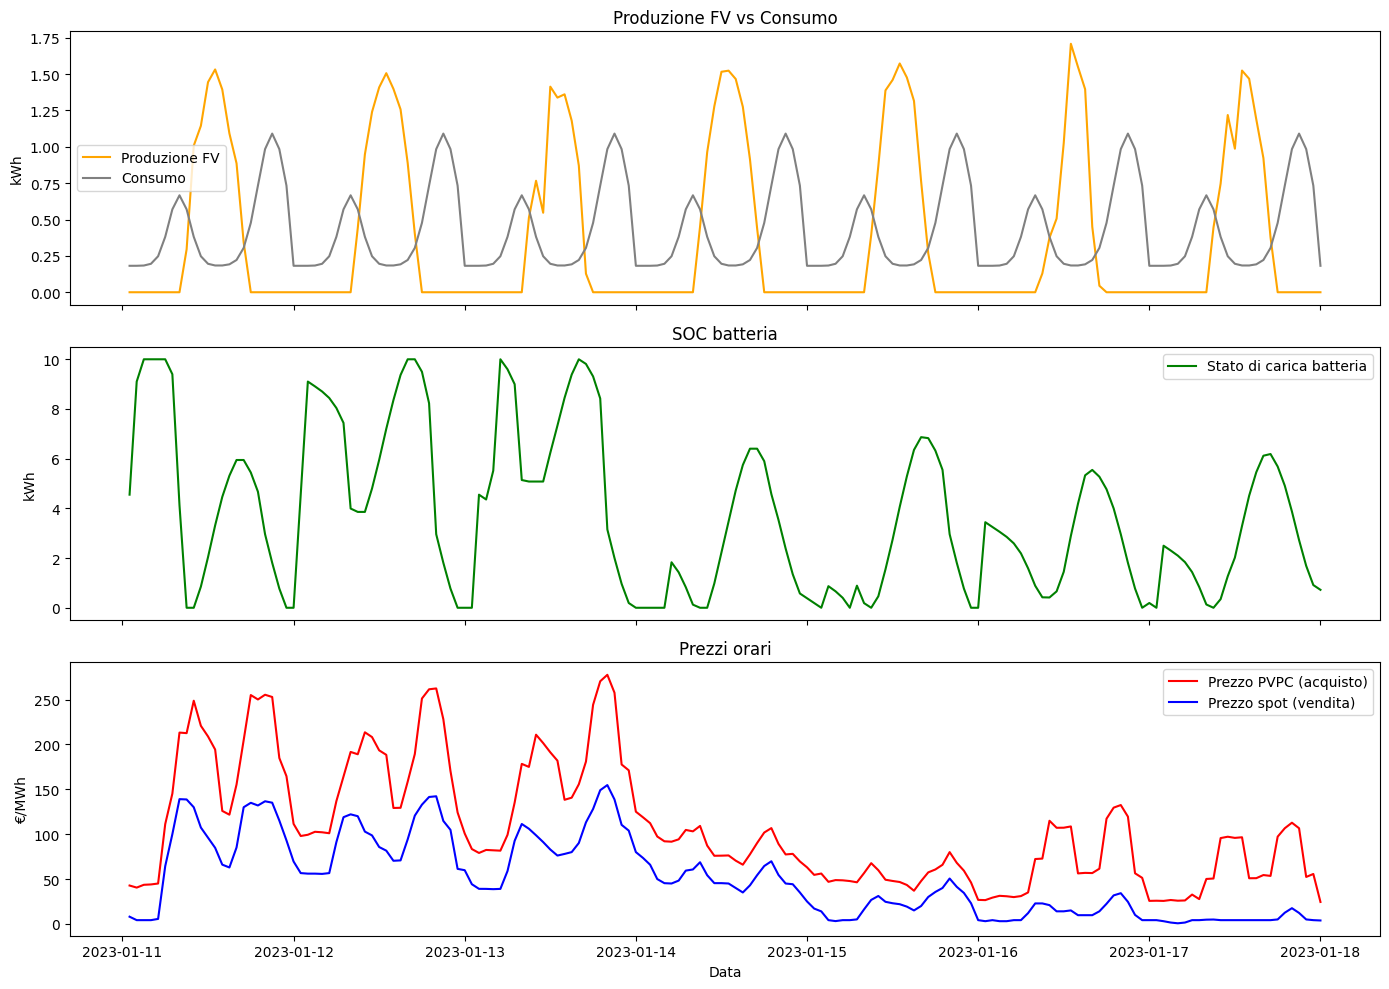

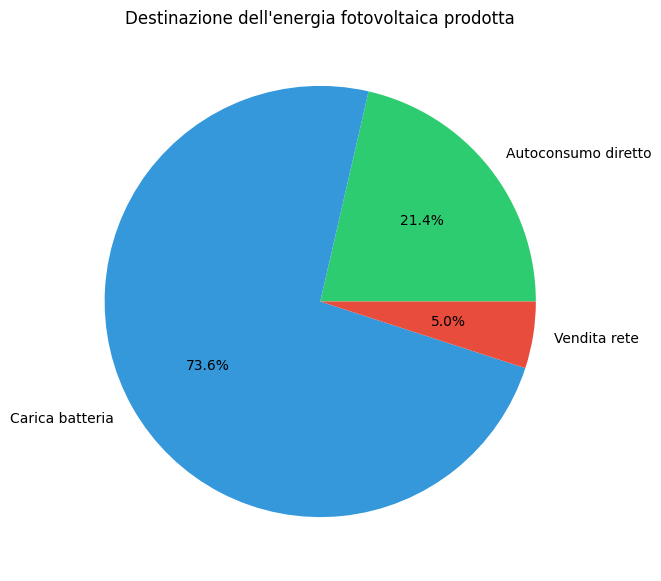

In [74]:
import matplotlib.pyplot as plt

# Grafico 1: una settimana tipo, per vedere i flussi in dettaglio
settimana = risultati_medio.iloc[24*10:24*17]  # giorni 10-17, esempio

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(settimana["datetime"], settimana["potenza_fv_kw"], label="Produzione FV", color="orange")
axes[0].plot(settimana["datetime"], settimana["consumo_medio_kwh"], label="Consumo", color="gray")
axes[0].set_ylabel("kWh")
axes[0].legend()
axes[0].set_title("Produzione FV vs Consumo")

axes[1].plot(settimana["datetime"], settimana["soc"], label="Stato di carica batteria", color="green")
axes[1].set_ylabel("kWh")
axes[1].legend()
axes[1].set_title("SOC batteria")

axes[2].plot(settimana["datetime"], settimana["prezzo_1001"], label="Prezzo PVPC (acquisto)", color="red")
axes[2].plot(settimana["datetime"], settimana["prezzo_600"], label="Prezzo spot (vendita)", color="blue")
axes[2].set_ylabel("€/MWh")
axes[2].legend()
axes[2].set_title("Prezzi orari")
axes[2].set_xlabel("Data")

plt.tight_layout()
plt.savefig("/content/grafico_settimana.png", dpi=150)
plt.show()

# Grafico 2: ripartizione annua dell'uso dell'energia FV (torta)
totale_autoconsumo = risultati_medio["fv_autoconsumo"].sum()
totale_carica_batteria = risultati_medio["carica_fv"].sum()
totale_vendita = risultati_medio["fv_vendita"].sum()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(
    [totale_autoconsumo, totale_carica_batteria, totale_vendita],
    labels=["Autoconsumo diretto", "Carica batteria", "Vendita rete"],
    autopct="%1.1f%%",
    colors=["#2ecc71", "#3498db", "#e74c3c"],
)
ax.set_title("Destinazione dell'energia fotovoltaica prodotta")
plt.savefig("/content/grafico_ripartizione_fv.png", dpi=150)
plt.show()

In [75]:
risultati_elevato, valore_elevato, status_elevato = ottimizza_arbitraggio_pv(
    df, "consumo_elevato_kwh"
)

costo_baseline_elevato = (df["consumo_elevato_kwh"] * df["prezzo_1001"] / 1000).sum()

confronto = pd.DataFrame({
    "Scenario": ["Consumo medio", "Consumo elevato (+ EV)"],
    "Consumo annuo stimato (kWh)": [CONSUMO_ANNUO_MEDIO_KWH, CONSUMO_ANNUO_ELEVATO_KWH],
    "Costo baseline (€, periodo dati)": [costo_baseline, costo_baseline_elevato],
    "Beneficio netto FV+batteria (€)": [
        valore_medio + costo_baseline,
        valore_elevato + costo_baseline_elevato,
    ],
})
confronto["Risparmio %"] = (
    confronto["Beneficio netto FV+batteria (€)"] / confronto["Costo baseline (€, periodo dati)"] * 100
).round(1)

print(confronto.to_string(index=False))

              Scenario  Consumo annuo stimato (kWh)  Costo baseline (€, periodo dati)  Beneficio netto FV+batteria (€)  Risparmio %
         Consumo medio                         3000                        249.805599                       537.538057        215.2
Consumo elevato (+ EV)                         5500                        457.976931                       789.820438        172.5


In [77]:
print("valore_medio:", valore_medio)
print("valore_elevato:", valore_elevato)
print("costo_baseline:", costo_baseline)
print("costo_baseline_elevato:", costo_baseline_elevato)

valore_medio: 287.7324587989582
valore_elevato: 331.84350710673726
costo_baseline: 249.80559866292478
costo_baseline_elevato: 457.97693088202874


In [78]:
ricavo_vendita_check = (risultati_medio["fv_vendita"] * risultati_medio["prezzo_600"] / 1000).sum()
print(f"Ricavo da sola vendita eccedenze: {ricavo_vendita_check:.2f} €")

Ricavo da sola vendita eccedenze: 8.60 €


In [79]:
prezzo_acq = risultati_medio["prezzo_1001"] / 1000
prezzo_vend = risultati_medio["prezzo_600"] / 1000

risparmio_autoconsumo = ((risultati_medio["fv_autoconsumo"] + risultati_medio["scarica_consumo"]) * prezzo_acq).sum()
ricavo_vendita = ((risultati_medio["fv_vendita"] + risultati_medio["scarica_vendita"]) * prezzo_vend).sum()
costo_acquisto_rete = (risultati_medio["acquisto_rete"] * prezzo_acq).sum()
costo_carica_rete = (risultati_medio["carica_rete"] * prezzo_acq).sum()
costo_degrado = 0.005 * (risultati_medio["carica_rete"] + risultati_medio["carica_fv"] + risultati_medio["scarica"]).sum()

print(f"Risparmio da autoconsumo (FV diretto + batteria): {risparmio_autoconsumo:.2f} €")
print(f"Ricavo da vendita eccedenze: {ricavo_vendita:.2f} €")
print(f"Costo acquisto rete: {costo_acquisto_rete:.2f} €")
print(f"Costo carica batteria da rete: {costo_carica_rete:.2f} €")
print(f"Costo degrado: {costo_degrado:.2f} €")
print(f"Somma (deve corrispondere a valore_medio = {valore_medio:.2f}):")
print(risparmio_autoconsumo + ricavo_vendita - costo_acquisto_rete - costo_carica_rete - costo_degrado)

Risparmio da autoconsumo (FV diretto + batteria): 249.81 €
Ricavo da vendita eccedenze: 91.56 €
Costo acquisto rete: 0.00 €
Costo carica batteria da rete: 35.74 €
Costo degrado: 17.90 €
Somma (deve corrispondere a valore_medio = 287.73):
287.7324587989613


In [80]:
ricavo_vendita_check = (risultati_medio["fv_vendita"] * risultati_medio["prezzo_600"] / 1000).sum()
print(f"Controllo 1: {ricavo_vendita_check:.2f} €")

ricavo_vendita_v2 = ((risultati_medio["fv_vendita"] + risultati_medio["scarica_vendita"]) * (risultati_medio["prezzo_600"] / 1000)).sum()
print(f"Controllo 2 (fv_vendita + scarica_vendita): {ricavo_vendita_v2:.2f} €")

vendita_batteria_sola = (risultati_medio["scarica_vendita"] * (risultati_medio["prezzo_600"] / 1000)).sum()
print(f"Solo vendita da batteria (scarica_vendita): {vendita_batteria_sola:.2f} €")

Controllo 1: 8.60 €
Controllo 2 (fv_vendita + scarica_vendita): 91.56 €
Solo vendita da batteria (scarica_vendita): 82.96 €


In [81]:
   from google.colab import files
   files.download("/content/grafico_settimana.png")
   files.download("/content/grafico_ripartizione_fv.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>